# Week 4 Activity 1 


## Task

1. Create a 2-qubit quantum circuit with a 90° phase shift and visualize it using the Q-sphere.
2. Create a circuit in qasm and import and run it in qiskit.
3. Draw any circuit random. But don't use dump method.

In [89]:
# libraries 

from math import pi
from qiskit import QuantumCircuit
import numpy as np
from qiskit.quantum_info import Statevector, DensityMatrix
from qiskit.visualization import plot_state_city, plot_histogram, plot_state_qsphere, plot_bloch_multivector
from IPython.display import display
from qiskit_aer import AerSimulator
import qiskit.qasm2, requests, os, json

## Task 1.

Create a 2-qubit quantum circuit with a 90° phase shift and visualize it using the Q-sphere.


### Circuit 1: Using Gate S

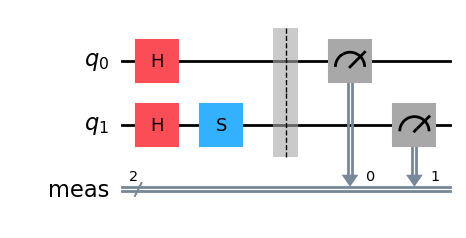

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

{'01': 22, '11': 21, '00': 29, '10': 28}


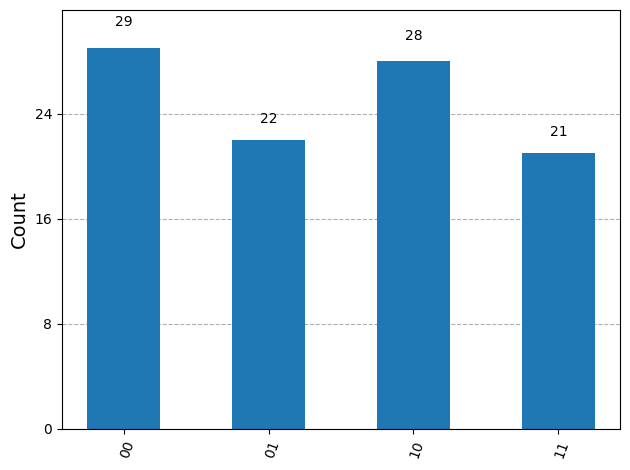

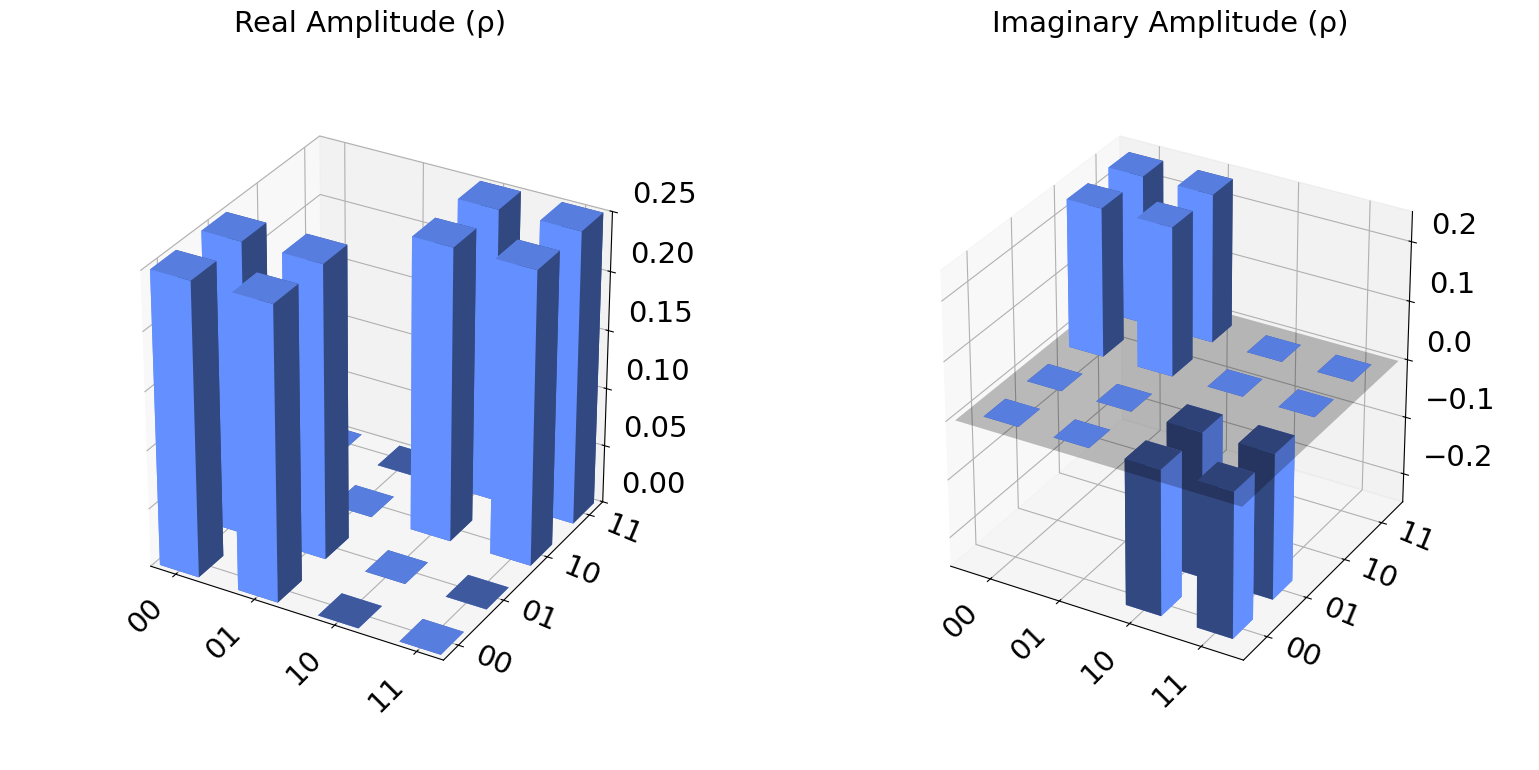

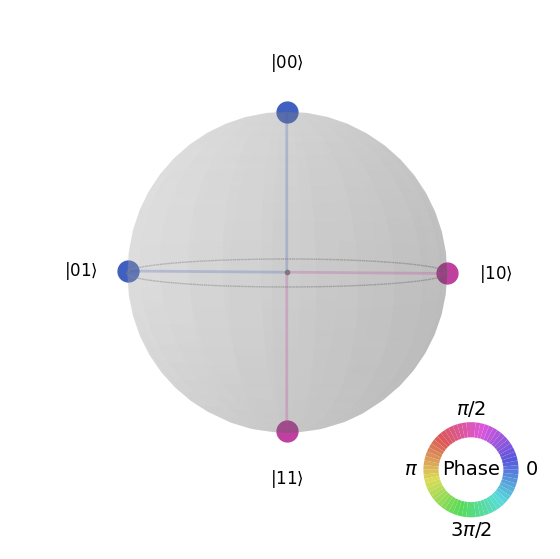

In [90]:
qc = QuantumCircuit(2)
qc.h(0)
qc.h(1)
qc.s(1)
psi = Statevector(qc)
qc.measure_all()  

simulator = AerSimulator()
job = simulator.run(qc, shots=100)
result = job.result()


display(qc.draw("mpl"))
display(psi.draw("latex"))                                
display(DensityMatrix(psi).draw("latex")) 
print(result.get_counts(qc))
display(plot_histogram(result.get_counts(qc)))
display(psi.draw("city"))                 
display(psi.draw("qsphere"))         

### Circuit 2. Using two T Gates

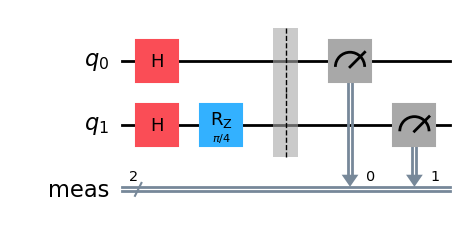

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

{'01': 30, '11': 18, '00': 25, '10': 27}


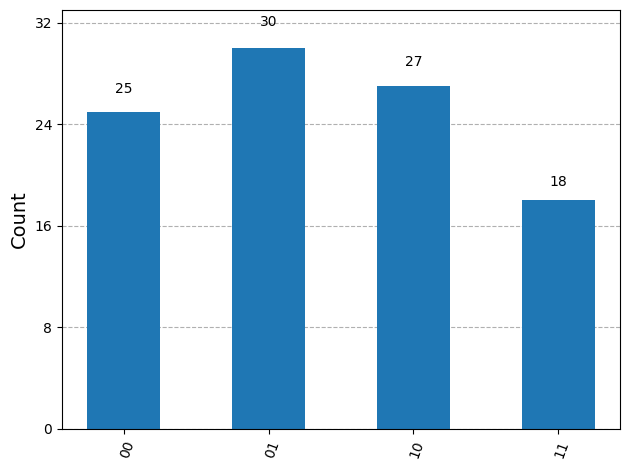

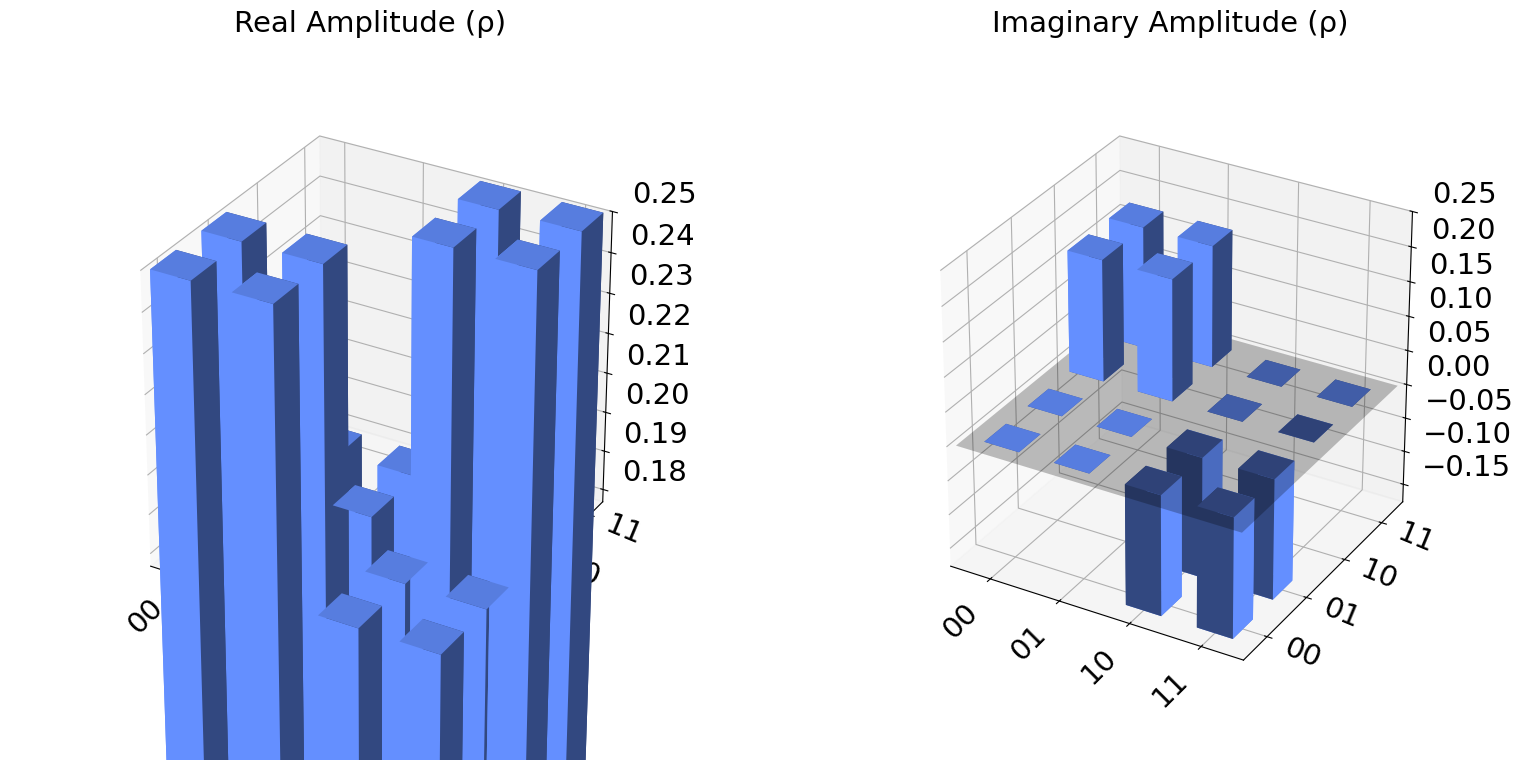

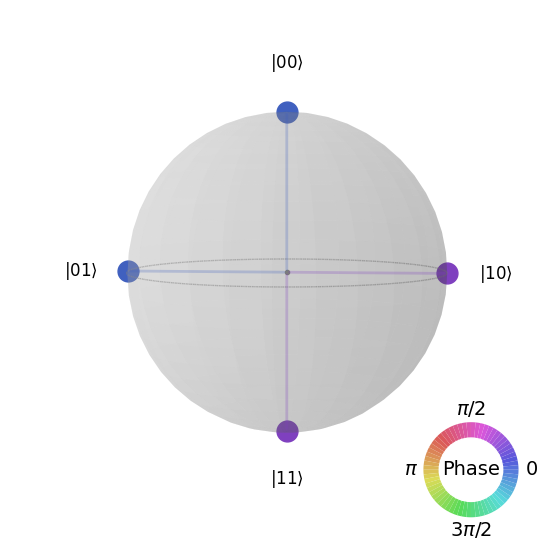

In [91]:
qc2 = QuantumCircuit(2)
qc2.h(0)
qc2.h(1)
qc2.rz(pi/4, 1)
psi2 = Statevector(qc2)
qc2.measure_all()  

simulator2 = AerSimulator()
job2 = simulator2.run(qc2, shots=100)
result2 = job2.result()

display(qc2.draw("mpl"))
display(psi2.draw("latex"))                                
display(DensityMatrix(psi2).draw("latex")) 
print(result2.get_counts(qc2))
display(plot_histogram(result2.get_counts(qc2)))
display(psi2.draw("city"))                 
display(psi2.draw("qsphere"))



## Task 2.1 Exporting a Circuit to QASM

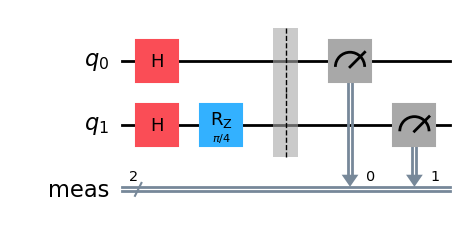

OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg meas[2];
h q[0];
h q[1];
rz(pi/4) q[1];
barrier q[0],q[1];
measure q[0] -> meas[0];
measure q[1] -> meas[1];


In [92]:
display(qc2.draw("mpl"))                    # circuit diagram
print(qiskit.qasm2.dumps(qc2))
qiskit.qasm2.dump(qc2, "task2.1.qasm")

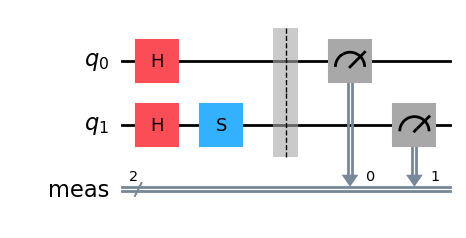

OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg meas[2];
h q[0];
h q[1];
s q[1];
barrier q[0],q[1];
measure q[0] -> meas[0];
measure q[1] -> meas[1];


In [93]:
display(qc.draw("mpl"))                    # circuit diagram
print(qiskit.qasm2.dumps(qc))
qiskit.qasm2.dump(qc, "task2.2.qasm")

## Task 2.2 Importing QASM to Qiskit

OPENQASM 2.0;
qreg q[2];
creg meas[2];
h q[0];
h q[1];
rz(pi/4) q[1];
barrier q[0],q[1];
measure q[0] -> meas[0];
measure q[1] -> meas[1];


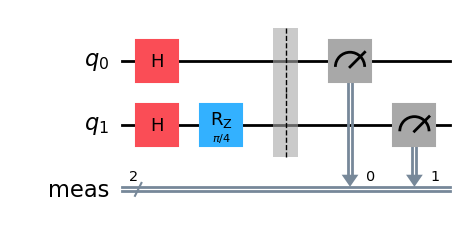

In [94]:
circuitS = qiskit.qasm2.load("task2.1.qasm")
req_str_qasm = 'http://quokka3.quokkacomputing.com/qsim/qasm'
code = qiskit.qasm2.dumps(circuitS)
code = code[:14] + code[(14 + 22):]

print(code)
display(circuitS.draw("mpl"))               

## 14. Sending the QASM Script to Quokka

In [95]:
data = {
    'script': code,
    'count': 100
}

result = requests.post(req_str_qasm, json=data)
json_obj = json.loads(result.content)

print(json_obj)


{'error': 'no error', 'error_code': 0, 'result': {'meas': [[1, 0], [1, 1], [0, 1], [0, 0], [0, 1], [0, 0], [0, 1], [1, 0], [0, 0], [1, 0], [0, 0], [1, 0], [0, 0], [1, 0], [0, 1], [0, 1], [0, 1], [1, 1], [1, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 0], [1, 1], [0, 0], [0, 1], [1, 1], [0, 0], [1, 0], [0, 0], [1, 1], [1, 1], [0, 0], [0, 1], [1, 1], [1, 1], [1, 1], [1, 0], [0, 0], [0, 0], [1, 1], [1, 0], [1, 1], [0, 0], [1, 0], [0, 1], [0, 0], [0, 0], [0, 0], [1, 0], [1, 1], [0, 1], [1, 1], [1, 1], [0, 0], [1, 1], [1, 1], [0, 0], [1, 1], [1, 1], [0, 1], [0, 1], [1, 0], [0, 1], [0, 0], [1, 0], [1, 1], [1, 1], [1, 0], [1, 0], [0, 1], [0, 0], [0, 0], [0, 0], [0, 1], [1, 1], [0, 1], [0, 0], [1, 1], [1, 0], [0, 1], [0, 0], [1, 0], [1, 1], [0, 1], [1, 1], [0, 0], [0, 0], [1, 0], [1, 0], [0, 0], [0, 0], [0, 0], [1, 0], [0, 0], [0, 1], [1, 1], [1, 0], [0, 1]]}}


AerSimulator: {'01': 30, '11': 18, '00': 25, '10': 27} (total 100 shots)
Quokka:       {'01': 20, '11': 26, '10': 24, '00': 30} (total 100 shots)


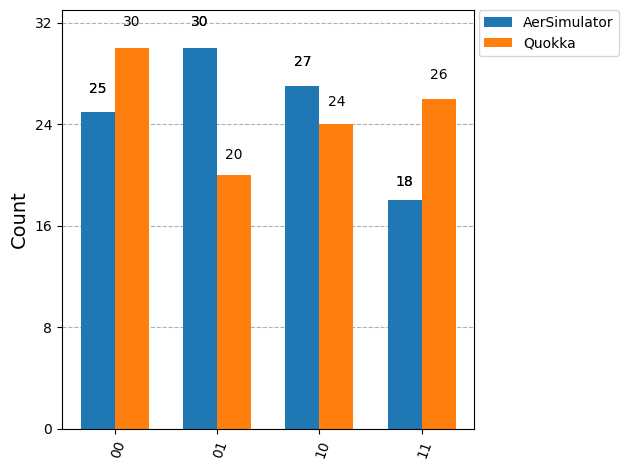

In [96]:
# Compare Quokka vs AerSimulator
# Expects: qc2 + result2 (AerSimulator cell) and json_obj (Quokka POST cell)
from collections import Counter

def quokka_to_counts(json_obj):
    # Quokka result = {register_name: [[c0, c1], ...]} -> one bit-list per shot
    shots = list(json_obj['result'].values())[0]
    counts = Counter()
    for shot in shots:
        # Qiskit labels bitstrings as c1c0 (qubit 0 on the right), so reverse to match
        bitstring = ''.join(str(b) for b in reversed(shot))
        counts[bitstring] += 1
    return dict(counts)

counts_aer    = result2.get_counts(qc2)
counts_quokka = quokka_to_counts(json_obj)

print("AerSimulator:", counts_aer,    "(total", sum(counts_aer.values()), "shots)")
print("Quokka:      ", counts_quokka, "(total", sum(counts_quokka.values()), "shots)")

display(plot_histogram([counts_aer, counts_quokka],
                       legend=['AerSimulator', 'Quokka']))
